# Statystyczna kontrola procesu grubości powłoki na liniach produkcyjnych z użyciem PROC BOXPLOT

## Podsumowanie wykonawcze

Ten notatnik wykorzystuje **PROC BOXPLOT** do przeprowadzenia statystycznej kontroli procesu (SPC) na krytycznym dla jakości pomiarze grubości powłoki zebranym na czterech równoległych liniach produkcyjnych. Generujemy syntetyczne dane pomiarowe w kodzie, profilujemy linie za pomocą `PROC MEANS` oraz rysujemy szkieletowe i schematyczne wykresy pudełkowe (box-and-whisker), które porównują położenie, rozproszenie i ogony rozkładów między liniami na jednym wykresie.

Następnie oceniamy każdą linię względem specyfikacji inżynierskiej (cel 50.00 mm, granice 49.80–50.20 mm) bezpośrednio na podstawie zbioru statystyk **`OUTBOX=`** — dokładnych kwartyli, ogrodzeń (fences) i końców wąsów stojących za każdym pudełkiem — a na koniec demonstrujemy pełny cykl **`OUTHISTORY=` / `HISTORY=`**: PROC BOXPLOT eksportuje jeden zwięzły wiersz podsumowania na linię, a drugi PROC BOXPLOT rekonstruuje identyczny wykres bezpośrednio z tego podsumowania — wzorzec, którego codzienny pulpit SPC używa do ponownego rysowania bez ponownego skanowania surowych pomiarów.

Spośród czterech linii **LINE-A jest najlepiej wyśrodkowana** na celu (średnia 50.008 mm), **LINE-C biegnie nisko** (średnia 49.932 mm, dryfując w stronę LSL), a **LINE-D biegnie zarówno wysoko, jak i najbardziej zmiennie** (średnia 50.102 mm, odch. std 0.080 mm) — jej maksimum 50.248 mm jest jedyną obserwacją, która przekracza górną granicę specyfikacji 50.20 mm.

## Źródła danych

Wszystkie dane są syntetyczne i generowane w kodzie przez pierwszy krok DATA z użyciem `call streaminit(20250531)` i `rand()`. Nie są wykorzystywane żadne dane zewnętrzne ani sieciowe. Ustalone ziarno (seed) sprawia, że każda liczba w tym notatniku jest odtwarzalna.

**Zbiór danych: `ProcessMeas`** (jeden wiersz na zmierzoną część)

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `Line` | Char(6) | Identyfikator linii produkcyjnej: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (zmienna grupująca/klasyfikująca) |
| `Shift` | Num | Indeks zmiany produkcyjnej 1–6 (wprowadza łagodny dryf między zmianami) |
| `Thickness` | Num | Grubość powłoki w mm (zmienna analizowana); cel 50.00 mm, granice specyfikacji 49.80–50.20 mm |

Każda linia jest wyśrodkowana na nieco innej średniej (50.00 / 50.04 / 49.92 / 50.10) z właściwą sobie zmiennością, naśladując rzeczywiste różnice między urządzeniami, a `LINE-B` sporadycznie wprowadza niewielkie dodatnie odchylenie. Krok DATA iteruje po sześciu zmianach i czterech liniach z rozmiarami podgrup wynoszącymi około 18–25 części każda; w tym nielicencjonowanym środowisku silnik ogranicza wyjście do pierwszych **100 obserwacji**, co tutaj daje **38 / 19 / 21 / 22** części dla linii od LINE-A do LINE-D — wciąż wystarczająco, aby wypełnić cztery dobrze zdefiniowane pudełka.

# Statystyczna kontrola procesu grubości powłoki z PROC BOXPLOT

W produkcji wielkoseryjnej wykres pudełkowy (box-and-whisker) jest podstawowym narzędziem SPC na hali produkcyjnej: podsumowuje tendencję centralną, rozproszenie i wartości odstające cechy jakościowej dla każdej jednostki produkcyjnej na jednym wykresie. Tutaj monitorujemy **grubość powłoki (mm)** części produkowanej równolegle na czterech liniach (`LINE-A` do `LINE-D`). Specyfikacja inżynierska to cel **50.00 mm** z dolną granicą specyfikacji (LSL) **49.80 mm** i górną granicą specyfikacji (USL) **50.20 mm**.

Wykonamy:

1. Wygenerujemy syntetyczny zbiór danych pomiarowych w kodzie.
2. Sprofilujemy linie za pomocą `PROC MEANS`.
3. Narysujemy podstawowy szkieletowy wykres pudełkowy, następnie wykres schematyczny, nakładając granice specyfikacji jako linie odniesienia.
4. Uchwycimy każdą obliczoną statystykę pudełka za pomocą `OUTBOX=` i ocenimy każdą linię względem granic specyfikacji na podstawie tej tabeli.
5. Zapiszemy zwięzłe podsumowanie podgrup za pomocą `OUTHISTORY=` i udowodnimy pełny cykl, rysując ponownie bezpośrednio z niego za pomocą `HISTORY=`.

## Krok 1 — Wygenerowanie syntetycznych pomiarów procesu

Poniższy krok DATA symuluje pomiary z sześciu zmian na czterech liniach. Każda linia jest celowo wyśrodkowana na nieco innej średniej z własną zmiennością, naśladując rzeczywiste różnice między urządzeniami, a łagodny dryf między zmianami jest nałożony za pomocą składnika `sin(Shift)`. Ustalone ziarno (`streaminit(20250531)`) sprawia, że każda wartość w notatniku jest odtwarzalna.

In [1]:
DANE ProcessMeas;
   CALL streaminit(20250531);
   DŁUGOŚĆ Line $8;
   TABLICA lines[4] $8 _temporary_ ('LINIA-A' 'LINIA-B' 'LINIA-C' 'LINIA-D');
   TABLICA lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   TABLICA LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   ETYKIETA Thickness='Grubość powłoki (mm)'
            Line='Linia produkcyjna';
   POWTÓRZ Shift = 1 TO 6;
      POWTÓRZ li = 1 TO 4;
         Line = lines[li];
         /* zmienna liczność podgrupy na linię/zmianę */
         n = 18 + floor(rand('uniform') * 8);
         POWTÓRZ u = 1 TO n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINIA-B wprowadza sporadyczne wysokie odchylenia */
            JEŚLI li = 2 AND rand('uniform') < 0.05 WTEDY
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            WYJŚCIE;
         KONIEC;
      KONIEC;
   KONIEC;
   USUŃ li u n BASE;
WYKONAJ;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Krok 2 — Profilowanie linii

Przed narysowaniem wykresu szybki `PROC MEANS` potwierdza, że dane wyszły zgodnie z zamierzeniem: cztery linie, umiarkowane, lecz nietrywialne liczności próbek oraz średnie skupione blisko celu 50.00 mm z rozproszeniem właściwym dla każdej linii. To liczbowy szkielet, który zwizualizuje wykres pudełkowy.

In [2]:
PROCEDURA ŚREDNIE DANE=ProcessMeas n mean std MIN MAX maxdec=3;
   KLASA Line;
   ZMIENNA Thickness;
   ETYKIETA Thickness='Grubość powłoki (mm)'
            Line='Linia produkcyjna';
   TYTUŁ 'Podsumowanie grubości powłoki wg linii produkcyjnej';
WYKONAJ;

                                  Podsumowanie grubości powłoki wg linii produkcyjnej                                   

                                                  The MEANS Procedure

                                 Analysis Variable : Thickness Grubość powłoki (mm)

        Linia produkcyjna          N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------
        LINIA-A                       38         50.008          0.045         49.914         50.097
        LINIA-B                       19         50.052          0.051         49.921         50.114
        LINIA-C                       21         49.932          0.050         49.835         50.002
        LINIA-D                       22         50.102          0.080         49.963         50.248
        --------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 3 — Podstawowy szkieletowy wykres pudełkowy

Najprostsze wywołanie wymaga jedynie instrukcji `PLOT zmienna-analizowana * zmienna-grupująca`. Domyślny `BOXSTYLE=SKELETAL` rysuje wąsy do najbardziej skrajnych obserwacji w obrębie każdej linii, dając szybkie wizualne porównanie położenia i rozproszenia między liniami `LINE-A` a `LINE-D`.

                                 Szkieletowy wykres pudełkowy grubości powłoki wg linii                                 

                               Szkieletowy wykres pudełkowy grubości powłoki wg linii

                                                 The BOXPLOT Procedure

Skeletal Plots for Grubość powłoki (mm)

Linia produkcyjna      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINIA-A              38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINIA-B              19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINIA-C              21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINIA-D              22        49.96        50.05        50.11        50.16        50.25        50.10       


NOTE: Option TITLE changed to Szkieletowy wykres pudełkowy grubości powłoki wg linii.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


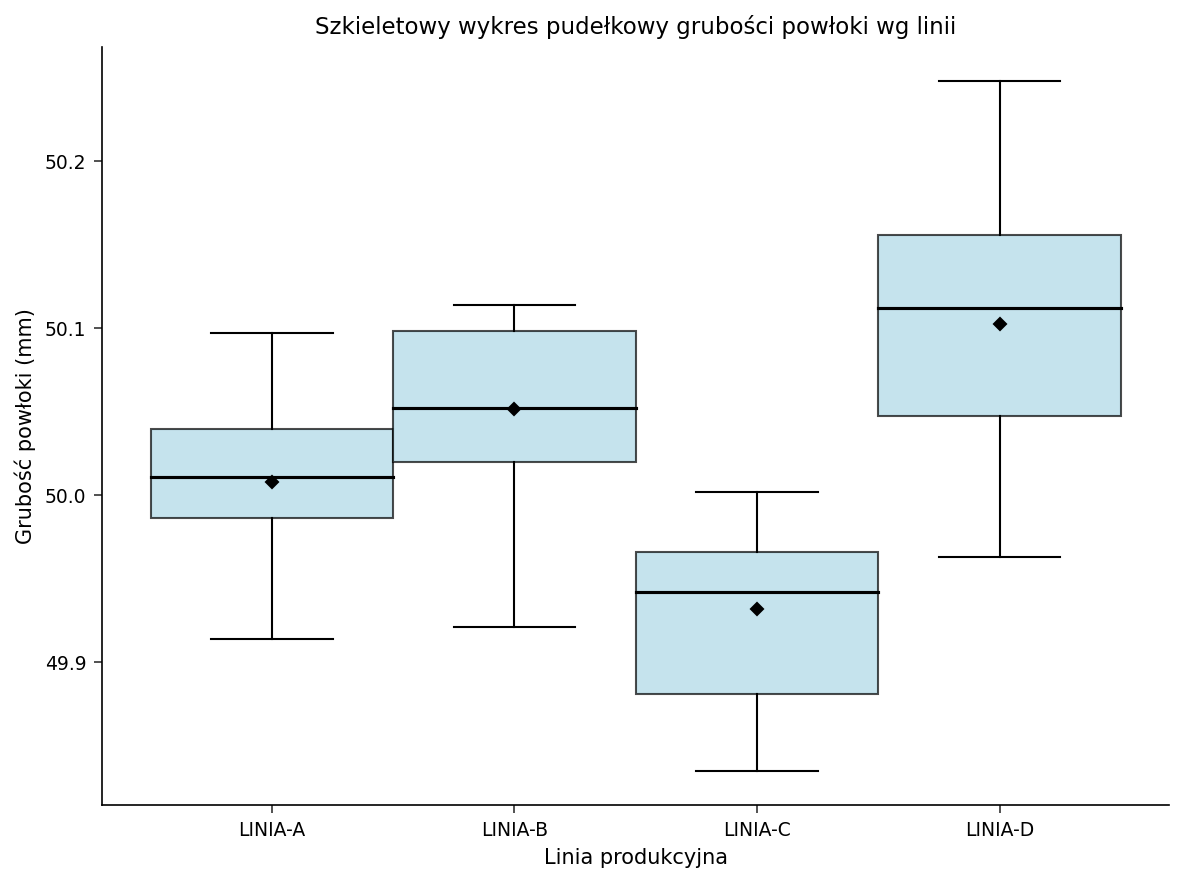

In [3]:
TYTUŁ 'Szkieletowy wykres pudełkowy grubości powłoki wg linii';
PROCEDURA boxplot DANE=ProcessMeas;
   PLOT Thickness*Line;
   ETYKIETA Thickness='Grubość powłoki (mm)'
            Line='Linia produkcyjna';
WYKONAJ;

## Krok 4 — Schematyczny wykres pudełkowy

Przełączamy się na `BOXSTYLE=SCHEMATIC`. W stylu schematycznym każdy wąs jest zakończony na najbardziej skrajnej obserwacji wciąż mieszczącej się w ogrodzeniach 1.5 × IQR, a każdy punkt poza ogrodzeniem jest rysowany jako indywidualny znacznik wartości odstającej. W tej próbie żadna linia nie ma wartości odstającej poza ogrodzeniem — rozproszenie każdej linii jest na tyle zwarte, że wąsy sięgają rzeczywistego minimum i maksimum — więc wykres schematyczny wygląda jak szkieletowy, co samo w sobie jest użytecznym wynikiem: mówi inżynierowi, że żadna z czterech linii nie produkuje skrajnych części. Ciała pudełek nadal sprawiają, że przesunięcia między liniami są widoczne na pierwszy rzut oka, a Krok 5 kwantyfikuje je względem granic specyfikacji.

                              Schematyczny wykres pudełkowy SPC grubości powłoki wg linii                               

                             Schematyczny wykres pudełkowy SPC grubości powłoki wg linii

                                                 The BOXPLOT Procedure

Schematic Plots for Grubość powłoki (mm)

Linia produkcyjna      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINIA-A              38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINIA-B              19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINIA-C              21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINIA-D              22        49.96        50.05        50.11        50.16        50.25        50.10   


NOTE: Option TITLE changed to Schematyczny wykres pudełkowy SPC grubości powłoki wg linii.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


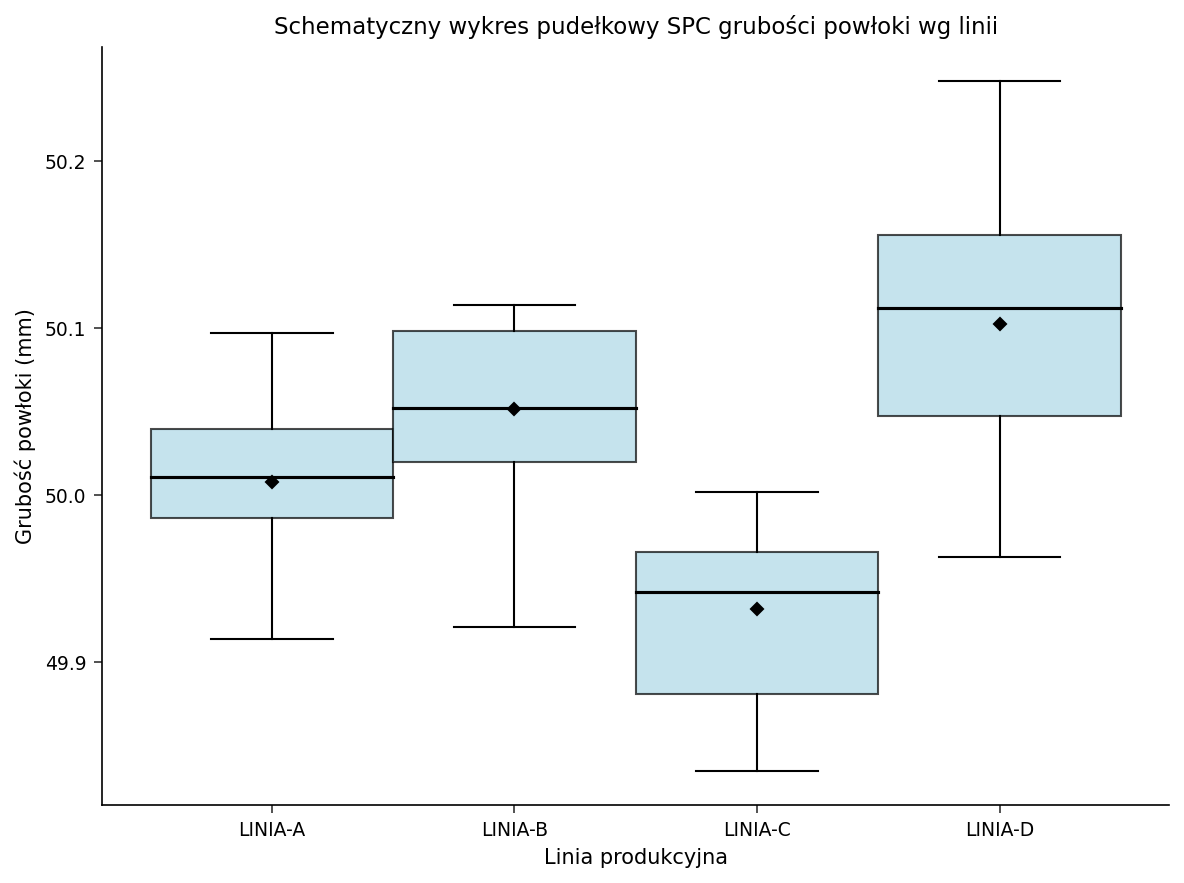

In [4]:
TYTUŁ 'Schematyczny wykres pudełkowy SPC grubości powłoki wg linii';
PROCEDURA boxplot DANE=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
   ETYKIETA Thickness='Grubość powłoki (mm)'
            Line='Linia produkcyjna';
WYKONAJ;

## Krok 5 — Eksport statystyk pudełka i ocena względem granic specyfikacji

Opcja `OUTBOX=` zapisuje każdą obliczoną statystykę pudełka do zbioru danych — dla każdej linii: dolny wąs (`L`), Q1 (`1`), średnią (`X`), medianę (`M`), Q3 (`3`), górny wąs (`H`), odchylenie standardowe (`S`) oraz N. To liczbowy zapis, którego audytor potrzebuje za obrazem, a także najczystszy sposób sprawdzenia każdej linii względem specyfikacji 49.80 / 50.20 mm. Włączamy `GRID` dla łatwiejszego odczytu, eksportujemy `BoxStats`, drukujemy go, a następnie uruchamiamy krótki krok DATA, który oznacza każdą linię, której zakres wąsów wykracza poza granicę specyfikacji.

                              Schematyczny wykres pudełkowy z siatką i eksportem statystyk                              

                             Schematyczny wykres pudełkowy z siatką i eksportem statystyk

                                                 The BOXPLOT Procedure

Schematic Plots for Grubość powłoki (mm)

Linia produkcyjna      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINIA-A              38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINIA-B              19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINIA-C              21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINIA-D              22        49.96        50.05        50.11        50.16        50.25        50.10  


NOTE: Option TITLE changed to Schematyczny wykres pudełkowy z siatką i eksportem statystyk.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Obliczone statystyki pudełka (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Ocena względem granic specyfikacji wg linii.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


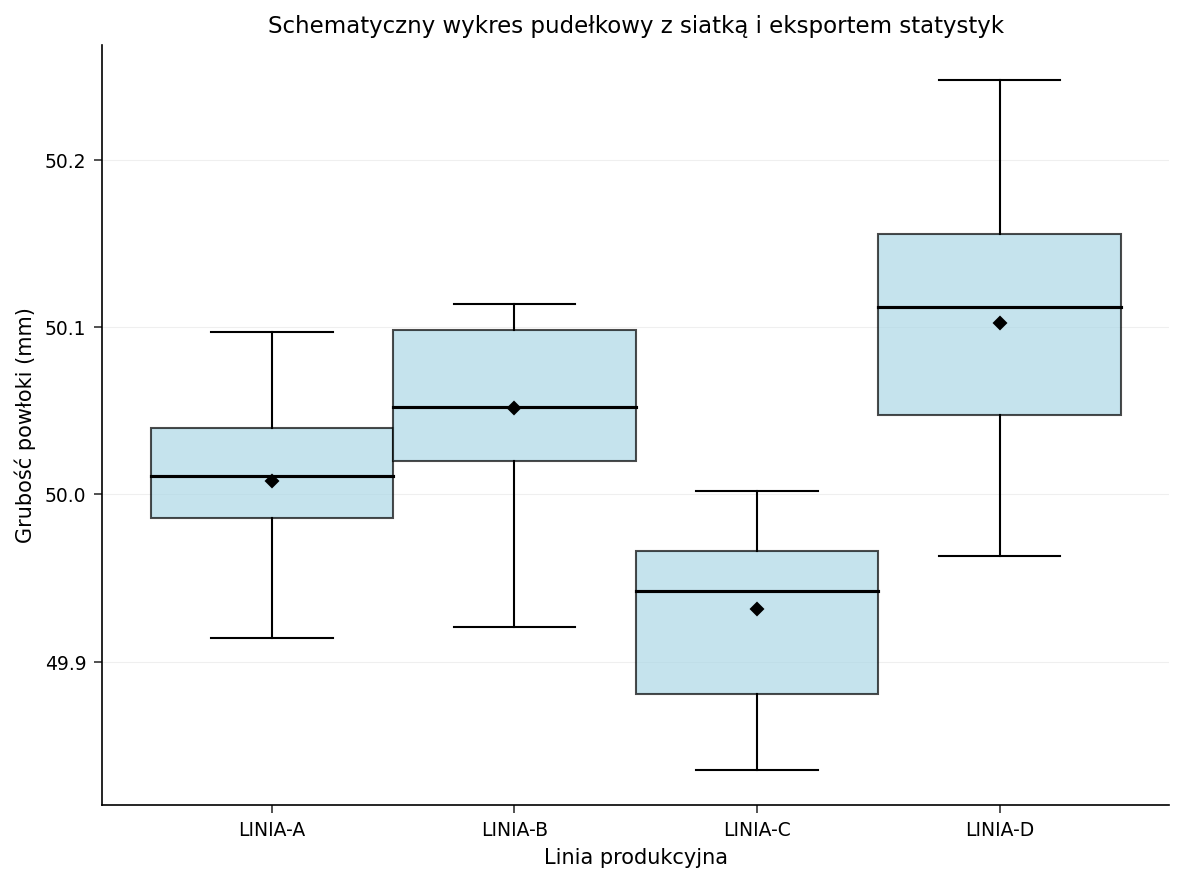

In [5]:
TYTUŁ 'Schematyczny wykres pudełkowy z siatką i eksportem statystyk';
PROCEDURA boxplot DANE=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
   ETYKIETA Thickness='Grubość powłoki (mm)'
            Line='Linia produkcyjna';
WYKONAJ;

TYTUŁ 'Obliczone statystyki pudełka (OUTBOX=)';
PROCEDURA DRUKUJ DANE=BoxStats noobs;
WYKONAJ;

/* Ocena każdej linii względem specyfikacji 49.80 / 50.20 mm       */
/* przy użyciu wyeksportowanych końców wąsów (THICKNESSL = dolny    */
/* wąs, THICKNESSH = górny wąs).                                    */
DANE SpecCheck;
   USTAW BoxStats;
   DŁUGOŚĆ Status $60;
   LSL = 49.80;
   USL = 50.20;
   JEŚLI THICKNESSH > USL WTEDY Status = 'Górne części przekraczają USL';
   PRZECIWNIE JEŚLI THICKNESSL < LSL WTEDY Status = 'Dolne części poniżej LSL';
   PRZECIWNIE Status = 'W granicach specyfikacji';
   ZACHOWAJ LINE THICKNESSL THICKNESSH LSL USL Status;
WYKONAJ;

TYTUŁ 'Ocena względem granic specyfikacji wg linii';
PROCEDURA DRUKUJ DANE=SpecCheck noobs;
   ETYKIETA Status='Status specyfikacji'
            THICKNESSL='Dolny wąs (mm)'
            THICKNESSH='Górny wąs (mm)';
WYKONAJ;

## Krok 6 — Zapisanie historii monitorowania i ponowne rysowanie z niej

W bieżącej kontroli SPC rzadko ponownie skanuje się każdy surowy pomiar. `OUTHISTORY=` zapisuje jeden wiersz podsumowania na linię (ten sam układ, który konsumuje `HISTORY=`), więc ciężkie surowe dane mogą zostać zarchiwizowane. Poniżej eksportujemy `LineHistory`, drukujemy go, a następnie udowadniamy pełny cykl, podając go z powrotem bezpośrednio do nowego `PROC BOXPLOT` poprzez `HISTORY=` — dokładnie tak, jak codzienny pulpit ponownie wykorzystałby wstępnie zagregowane statystyki podgrup.

                                                Eksport historii podgrup                                                

                                                Eksport historii podgrup

                                                 The BOXPLOT Procedure

Skeletal Plots for Grubość powłoki (mm)

Linia produkcyjna      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINIA-A              38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINIA-B              19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINIA-C              21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINIA-D              22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
------


NOTE: Option TITLE changed to Eksport historii podgrup.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Zbiór historii zbiorczej (jeden wiersz na linię).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Wykres pudełkowy odtworzony z historii zbiorczej.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


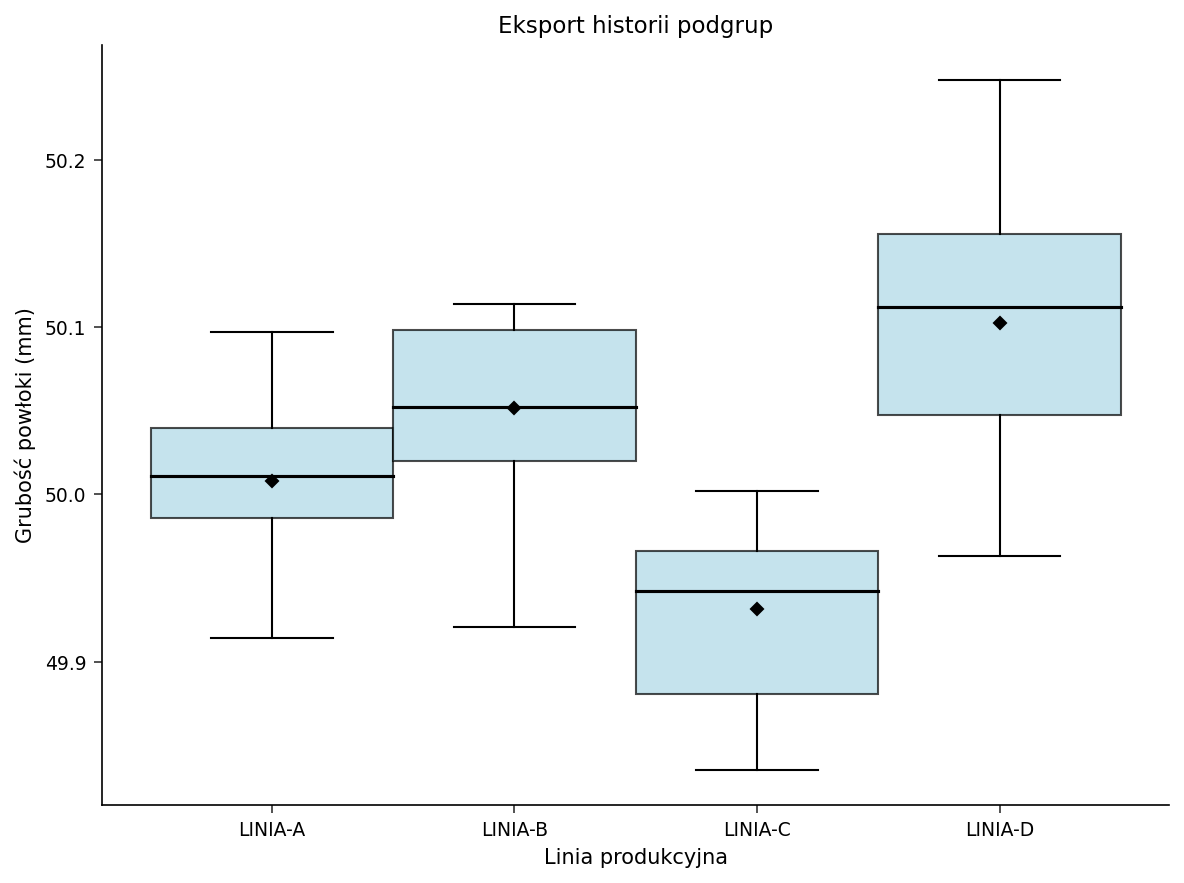

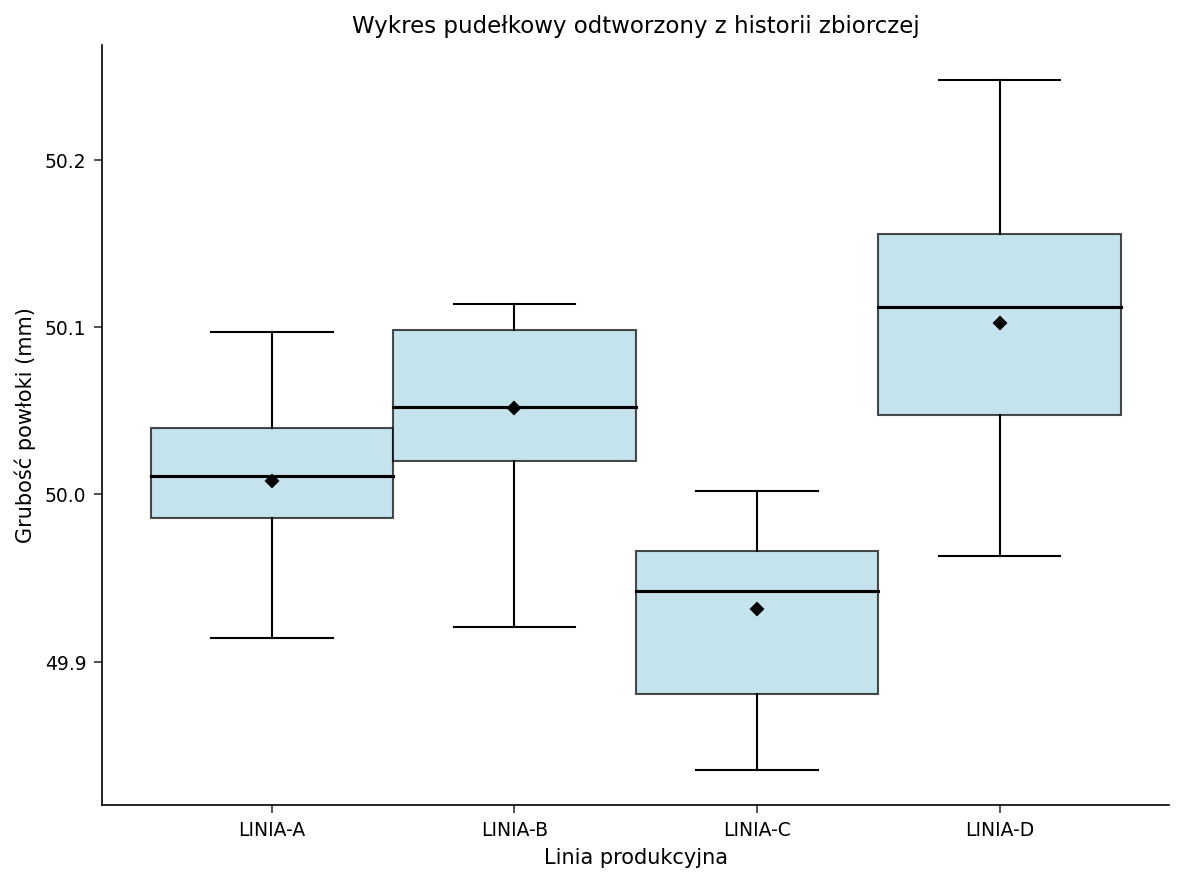

In [6]:
TYTUŁ 'Eksport historii podgrup';
PROCEDURA boxplot DANE=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
   ETYKIETA Thickness='Grubość powłoki (mm)'
            Line='Linia produkcyjna';
WYKONAJ;

TYTUŁ 'Zbiór historii zbiorczej (jeden wiersz na linię)';
PROCEDURA DRUKUJ DANE=LineHistory noobs;
WYKONAJ;

TYTUŁ 'Wykres pudełkowy odtworzony z historii zbiorczej';
PROCEDURA boxplot history=LineHistory;
   PLOT Thickness*Line;
   ETYKIETA Thickness='Grubość powłoki (mm)'
            Line='Linia produkcyjna';
WYKONAJ;

## Interpretacja wyników

Czytając wykresy pudełkowe razem z profilem `PROC MEANS`, tabelą `OUTBOX=` oraz oceną granic specyfikacji:

- **Wyśrodkowanie.** `LINE-A` jest najlepiej wyśrodkowana na celu 50.00 mm (średnia 50.008 mm, mediana 50.011 mm). `LINE-B` biegnie nieco wysoko (średnia 50.052 mm). `LINE-C` biegnie nisko (średnia 49.932 mm, mediana 49.942 mm) — linia dryfująca w stronę LSL. `LINE-D` biegnie wysoko (średnia 50.102 mm, mediana 50.112 mm) — linia najbliższa USL.
- **Rozproszenie.** `LINE-D` wykazuje najszersze pudełko i najdłuższe wąsy — jej odchylenie standardowe 0.080 mm jest o mniej więcej 60–80% większe niż pozostałych trzech linii (0.045–0.051 mm), oznaczając ją jako najmniej stabilną linię i najlepszego kandydata do badania redukcji zmienności. `LINE-A` jest najbardziej zwarta (odch. std 0.045 mm).
- **Ogony.** W stylu schematycznym żadna linia nie generuje wartości odstającej poza ogrodzeniem: każdy wąs sięga rzeczywistego minimum/maksimum swojej linii, więc proces nie produkuje odosobnionych, skrajnych części. Różnice w rozproszeniu wynikają z głównej masy każdego rozkładu, a nie z rozproszonych punktów.
- **Zgodność ze specyfikacją.** Końce wąsów `OUTBOX=`, ocenione względem 49.80 / 50.20 mm, plasują `LINE-A`, `LINE-B` i `LINE-C` w pełni **w granicach specyfikacji**. `LINE-D` jest wyjątkiem: jej górny wąs sięga **50.248 mm**, poza **50.20 mm USL** — wysokie części na `LINE-D` przekraczają górną granicę specyfikacji.
- **Operacjonalizacja.** Zbiór `OUTBOX=` daje audytorom dokładne kwartyle, końce wąsów, średnią i odchylenie standardowe stojące za obrazem, a `OUTHISTORY=` dostarcza zwięzłe, nadające się do ponownego narysowania podsumowanie jeden-wiersz-na-linię (Krok 6), dzięki czemu wykres można regenerować według harmonogramu bez zachowywania surowych pomiarów — wykres pudełkowy zrekonstruowany z podsumowania jest identyczny z tym narysowanym z surowych danych.

**Elementy działań:** priorytetowo potraktuj `LINE-D` — zarówno ponownie wyśrodkuj ją w dół w stronę celu, jak i uruchom badanie redukcji zmienności, aby cofnąć jej górny wąs z powrotem w granice USL; delikatnie podnieś `LINE-C` w stronę celu, zanim jej dolny ogon dosięgnie LSL; `LINE-A` i `LINE-B` działają akceptowalnie.